# ARIMA

## Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

## Importação de dataset

In [2]:
data = pd.read_csv("/content/carne-brasileira-derivada.csv", encoding='utf-8', sep=',')
data.head()

,tipo_carne,ano,trimestre,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,...,exportacao_usd_diff_1,exportacao_usd_pct_change_a,preco_medio_ton_usd_lag1,preco_medio_ton_usd_lag2,preco_medio_ton_usd_lag3,preco_medio_ton_usd_lag4,preco_medio_ton_usd_rolling_mean_4,preco_medio_ton_usd_ewm_4,preco_medio_ton_usd_diff_1,preco_medio_ton_usd_pct_change_a
0,bovino,2015,1,215.20,7.737,1.836,0.993,2.87,22.95,60.01,...,-0.526,-0.261710,4.858,4.874,4.729,4.403,4.71600,4.744984,-0.579,-0.028163
1,bovino,2015,2,215.20,7.626,1.844,1.094,3.07,20.92,57.96,...,0.101,-0.209538,4.279,4.858,4.874,4.729,4.68500,4.558590,-0.049,-0.105519
2,bovino,2015,3,215.20,7.578,1.877,1.258,3.59,23.80,69.05,...,0.164,-0.186813,4.230,4.279,4.858,4.874,4.56025,4.427154,0.328,-0.064834
3,bovino,2015,4,215.20,7.693,1.929,1.319,3.83,27.76,70.20,...,0.061,-0.131666,4.558,4.230,4.279,4.858,4.48125,4.479493,-0.336,-0.130918
4,bovino,2016,1,218.23,7.303,1.797,1.094,3.82,36.46,65.52,...,-0.225,0.101712,4.222,4.558,4.230,4.279,4.32225,4.376496,0.008,-0.011451


## Separação de dataset por carne

In [3]:
bovino = data[data['tipo_carne'] == 'bovino'].copy()
bovino.head()

,tipo_carne,ano,trimestre,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,...,exportacao_usd_diff_1,exportacao_usd_pct_change_a,preco_medio_ton_usd_lag1,preco_medio_ton_usd_lag2,preco_medio_ton_usd_lag3,preco_medio_ton_usd_lag4,preco_medio_ton_usd_rolling_mean_4,preco_medio_ton_usd_ewm_4,preco_medio_ton_usd_diff_1,preco_medio_ton_usd_pct_change_a
0,bovino,2015,1,215.20,7.737,1.836,0.993,2.87,22.95,60.01,...,-0.526,-0.261710,4.858,4.874,4.729,4.403,4.71600,4.744984,-0.579,-0.028163
1,bovino,2015,2,215.20,7.626,1.844,1.094,3.07,20.92,57.96,...,0.101,-0.209538,4.279,4.858,4.874,4.729,4.68500,4.558590,-0.049,-0.105519
2,bovino,2015,3,215.20,7.578,1.877,1.258,3.59,23.80,69.05,...,0.164,-0.186813,4.230,4.279,4.858,4.874,4.56025,4.427154,0.328,-0.064834
3,bovino,2015,4,215.20,7.693,1.929,1.319,3.83,27.76,70.20,...,0.061,-0.131666,4.558,4.230,4.279,4.858,4.48125,4.479493,-0.336,-0.130918
4,bovino,2016,1,218.23,7.303,1.797,1.094,3.82,36.46,65.52,...,-0.225,0.101712,4.222,4.558,4.230,4.279,4.32225,4.376496,0.008,-0.011451


In [4]:
suino = data[data['tipo_carne'] == 'suino'].copy()
suino.head()

,tipo_carne,ano,trimestre,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,...,exportacao_usd_diff_1,exportacao_usd_pct_change_a,preco_medio_ton_usd_lag1,preco_medio_ton_usd_lag2,preco_medio_ton_usd_lag3,preco_medio_ton_usd_lag4,preco_medio_ton_usd_rolling_mean_4,preco_medio_ton_usd_ewm_4,preco_medio_ton_usd_diff_1,preco_medio_ton_usd_pct_change_a
80,suino,2015,1,40.33,9.170,0.794,0.197,2.87,22.95,60.01,...,-0.213,-0.242308,3.674,3.774,3.471,2.811,3.43250,3.482360,-1.085,-0.078975
81,suino,2015,2,40.33,9.700,0.860,0.300,3.07,20.92,57.96,...,0.103,-0.200000,2.589,3.674,3.774,3.471,3.37700,3.125016,-0.024,-0.261020
82,suino,2015,3,40.33,10.184,0.897,0.367,3.59,23.80,69.05,...,0.067,-0.080201,2.565,2.589,3.674,3.774,3.15050,2.901010,0.022,-0.314520
83,suino,2015,4,40.33,10.216,0.877,0.301,3.83,27.76,70.20,...,-0.066,-0.265854,2.587,2.565,2.589,3.674,2.85375,2.775406,-0.382,-0.399837
84,suino,2016,1,39.95,10.061,0.878,0.247,3.82,36.46,65.52,...,-0.054,0.253807,2.205,2.587,2.565,2.589,2.48650,2.547243,-0.436,-0.316725


In [5]:
frango = data[data['tipo_carne'] == 'frango'].copy()
frango.head()

,tipo_carne,ano,trimestre,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,...,exportacao_usd_diff_1,exportacao_usd_pct_change_a,preco_medio_ton_usd_lag1,preco_medio_ton_usd_lag2,preco_medio_ton_usd_lag3,preco_medio_ton_usd_lag4,preco_medio_ton_usd_rolling_mean_4,preco_medio_ton_usd_ewm_4,preco_medio_ton_usd_diff_1,preco_medio_ton_usd_pct_change_a
40,frango,2015,1,1330.0,1.382,3.164,1.354,2.87,22.95,60.01,...,-0.422,-0.078912,1.891,1.939,1.932,1.779,1.88525,1.884232,-0.264,-0.085441
41,frango,2015,2,1330.0,1.402,3.268,1.611,3.07,20.92,57.96,...,0.257,-0.086735,1.627,1.891,1.939,1.932,1.84725,1.781339,0.044,-0.135093
42,frango,2015,3,1330.0,1.503,3.376,1.770,3.59,23.80,69.05,...,0.159,-0.059011,1.671,1.627,1.891,1.939,1.78200,1.737204,-0.044,-0.160908
43,frango,2015,4,1330.0,1.506,3.330,1.493,3.83,27.76,70.20,...,-0.277,-0.159347,1.627,1.671,1.627,1.891,1.70400,1.693122,-0.140,-0.213644
44,frango,2016,1,1350.0,1.403,3.290,1.287,3.82,36.46,65.52,...,-0.206,-0.049483,1.487,1.627,1.671,1.627,1.60300,1.610673,-0.122,-0.161033


### Ordenação temporal

In [6]:
bovino = bovino.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

In [7]:
suino = suino.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

In [8]:
frango = frango.sort_values(by=['ano', 'trimestre']).reset_index(drop=True)

## Adequação do dataset para o ARIMA

### Bovino

In [9]:
df = bovino.copy()
df = df.sort_index()
series = df['exportacao_usd']

series

,exportacao_usd
0,0.993
1,1.094
2,1.258
3,1.319
4,1.094
5,1.117
6,1.065
7,1.059
8,1.079
9,1.094


#### Visualização da série

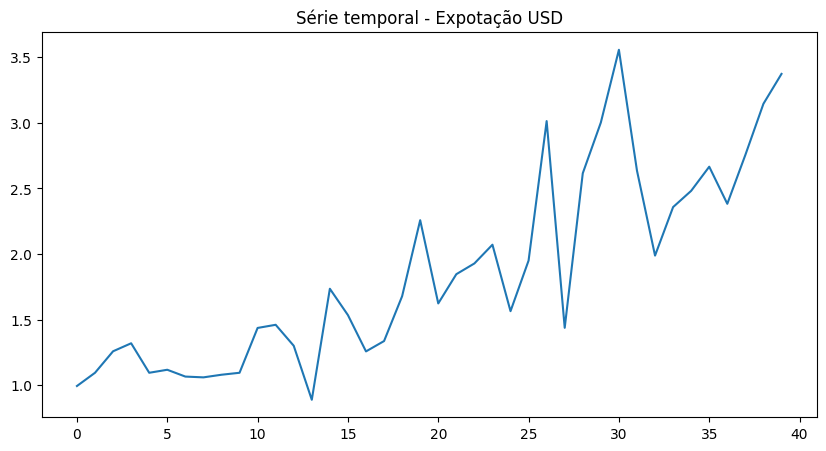

In [10]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Série temporal - Expotação USD")
plt.show()

#### Testar estacionariedade

In [11]:
result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.009754289622542595
p-value: 0.9593313634267757


**Interpretação**:

* p < 0.05 → estacionária
* p > 0.05 → precisa diferenciar (d > 0)

#### Tornar estacionário

In [12]:
series_diff = series.diff().dropna()

result = adfuller(series_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.3641833444841645
p-value: 2.4327317468697795e-08


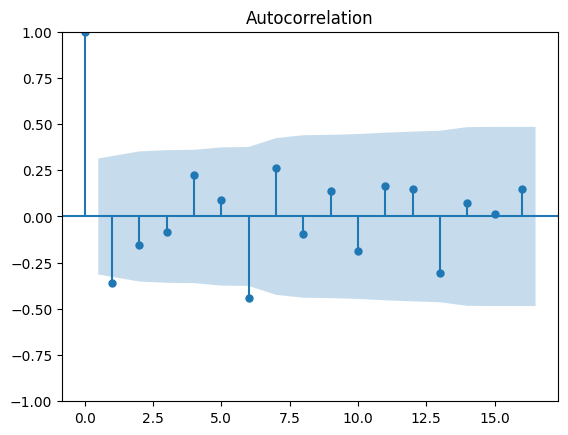

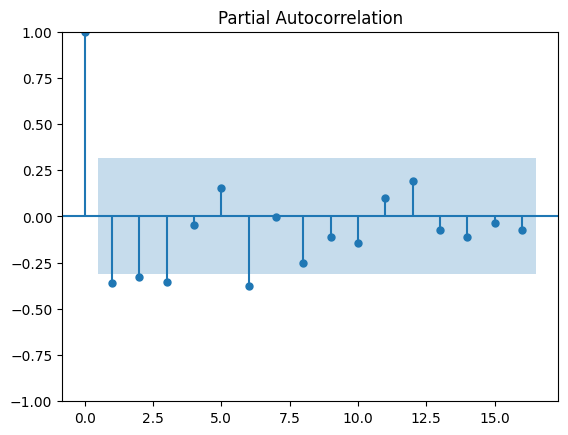

In [13]:
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

**Interpretação**:

* X-axis → lag
* Y-axis → força de correlação
* Pontos fora da área de confiança → correlação significativa

#### Treinamento do modelo ARIMA

In [14]:
model = ARIMA(series, order=(0, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   40
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -23.775
Date:                Sun, 26 Apr 2026   AIC                             51.550
Time:                        15:34:46   BIC                             54.877
Sample:                             0   HQIC                            52.743
                                 - 40                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6044      0.102     -5.898      0.000      -0.805      -0.404
sigma2         0.1959      0.040      4.950      0.000       0.118       0.273
Ljung-Box (L1) (Q):                   0.06   Jarque-

#### Diagnóstico dos resíduos

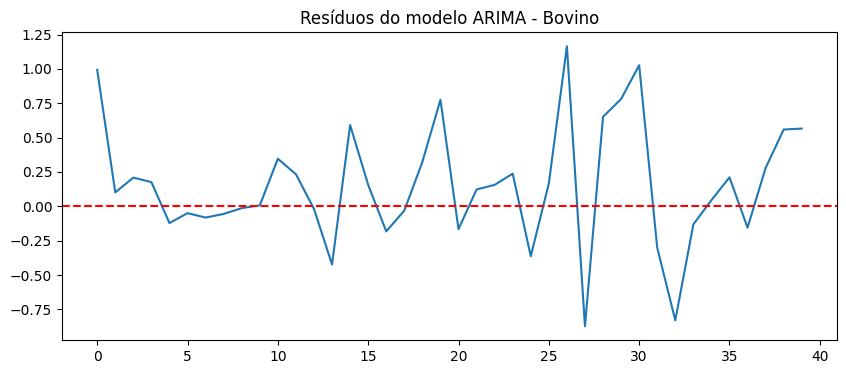

<Figure size 1000x400 with 0 Axes>

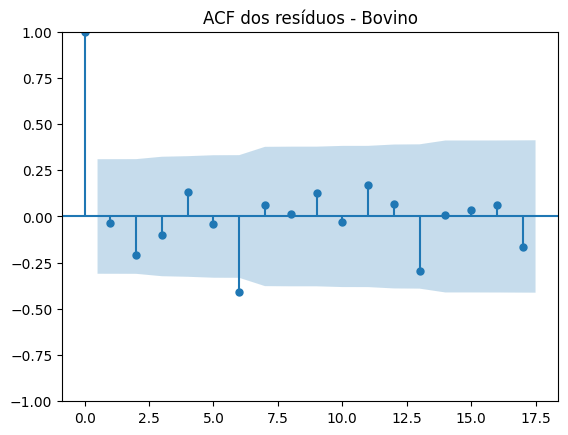

Ljung-Box test (lag 10):
      lb_stat  lb_pvalue
10  12.635154   0.244792


In [15]:
residuals = model_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos do modelo ARIMA - Bovino')
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(residuals)
plt.title('ACF dos resíduos - Bovino')
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print('Ljung-Box test (lag 10):')
print(lb_test)

#### Realizando previsões

In [16]:
forecast = model_fit.forecast(steps=5)

print(forecast)

40    3.032142
41    3.032142
42    3.032142
43    3.032142
44    3.032142
Name: predicted_mean, dtype: float64


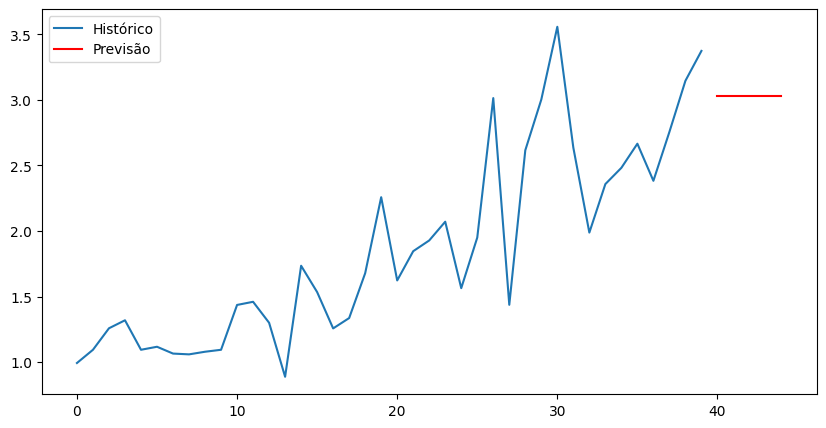

In [17]:
plt.figure(figsize=(10,5))

plt.plot(series, label='Histórico')
plt.plot(forecast, label='Previsão', color='red')

plt.legend()
plt.show()

In [18]:
train_size = int(len(series) * 0.8)

train, test = series[:train_size], series[train_size:]

model = ARIMA(train, order=(2,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test, predictions)


print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 0.3150659793470521
RMSE: 0.5613073840125855
R²: -0.7946995249413518


### Suíno

In [19]:
df = suino.copy()
df = df.sort_index()
series = df['exportacao_usd']

series

,exportacao_usd
0,0.197
1,0.300
2,0.367
3,0.301
4,0.247
5,0.326
6,0.392
7,0.383
8,0.365
9,0.374


#### Visualização da série

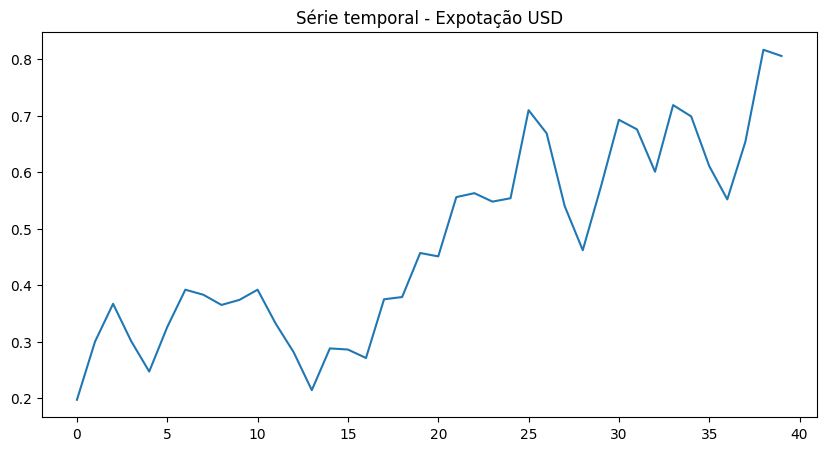

In [20]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Série temporal - Expotação USD")
plt.show()

#### Testar estacionariedade

In [21]:
result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.04584209759953825
p-value: 0.9621629462876569


#### Tornar estacionário

In [22]:
series_diff = series.diff().dropna()

result = adfuller(series_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.6303809493527996
p-value: 0.08687928940811673


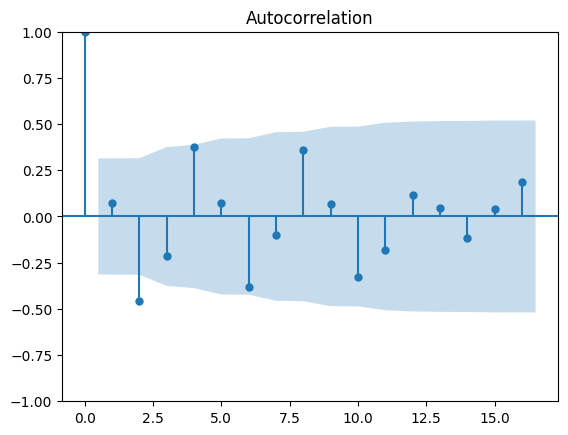

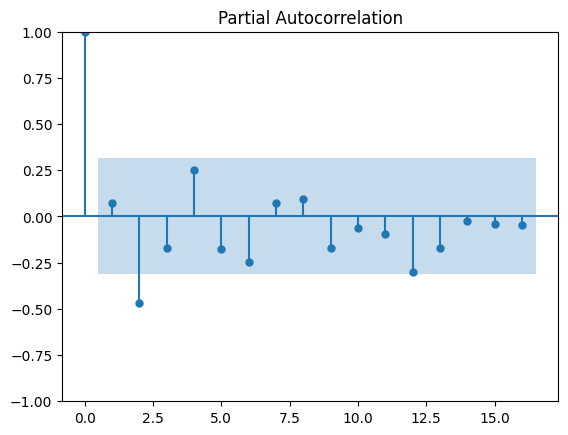

In [23]:
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

#### Treinamento do modelo ARIMA

In [24]:
model = ARIMA(series, order=(2, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   40
Model:                 ARIMA(2, 1, 0)   Log Likelihood                  50.395
Date:                Sun, 26 Apr 2026   AIC                            -94.790
Time:                        15:34:50   BIC                            -89.799
Sample:                             0   HQIC                           -92.999
                                 - 40                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1548      0.162      0.954      0.340      -0.163       0.473
ar.L2         -0.4977      0.172     -2.898      0.004      -0.834      -0.161
sigma2         0.0044      0.001      3.988      0.0

#### Diagnóstico dos resíduos

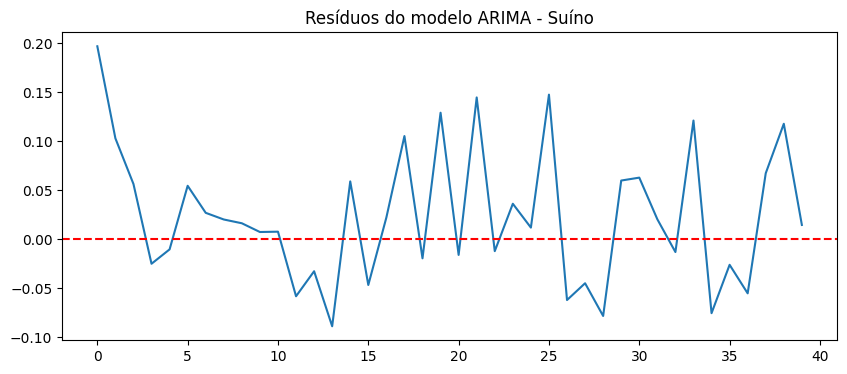

<Figure size 1000x400 with 0 Axes>

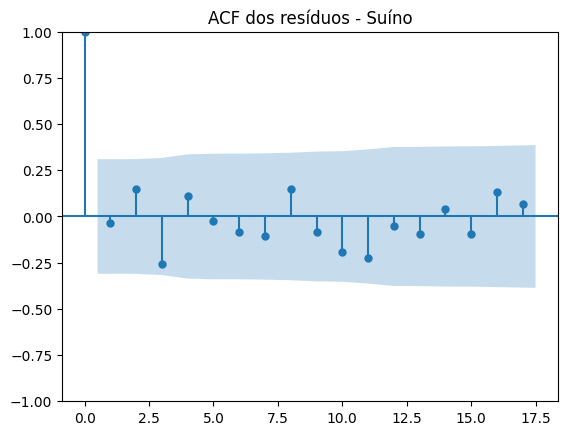

Ljung-Box test (lag 10):
    lb_stat  lb_pvalue
10  9.14913   0.518012


In [25]:
residuals = model_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos do modelo ARIMA - Suíno')
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(residuals)
plt.title('ACF dos resíduos - Suíno')
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print('Ljung-Box test (lag 10):')
print(lb_test)

#### Realizando previsões

In [26]:
forecast = model_fit.forecast(steps=5)

print(forecast)

40    0.723180
41    0.715834
42    0.755913
43    0.765772
44    0.747353
Name: predicted_mean, dtype: float64


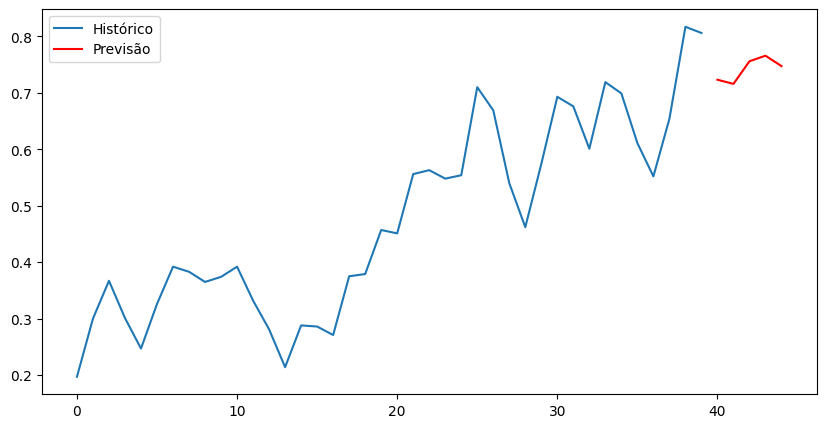

In [27]:
plt.figure(figsize=(10,5))

plt.plot(series, label='Histórico')
plt.plot(forecast, label='Previsão', color='red')

plt.legend()
plt.show()

In [28]:
train_size = int(len(series) * 0.8)

train, test = series[:train_size], series[train_size:]

model = ARIMA(train, order=(2,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 0.01012496418181744
RMSE: 0.10062288100535305
R²: -0.25495584909551106


### Frango

In [29]:
df = frango.copy()
df = df.sort_index()
series = df['exportacao_usd']

series

,exportacao_usd
0,1.354
1,1.611
2,1.770
3,1.493
4,1.287
5,1.668
6,1.611
7,1.379
8,1.595
9,1.574


#### Visualização da série

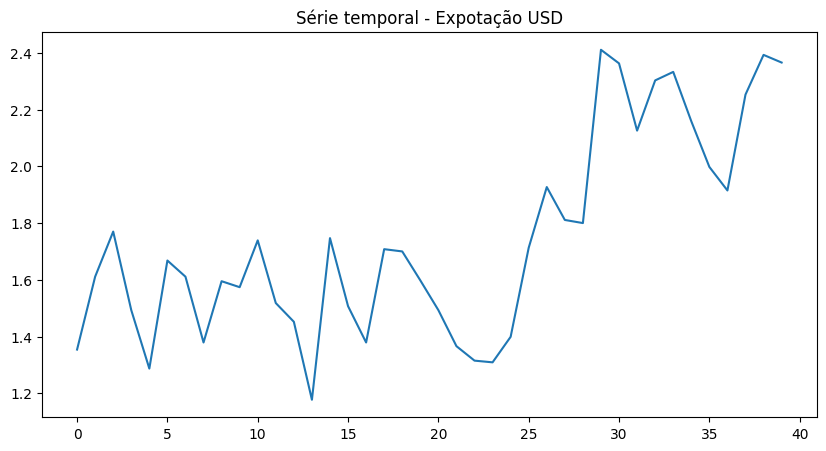

In [30]:
plt.figure(figsize=(10,5))
plt.plot(series)
plt.title("Série temporal - Expotação USD")
plt.show()

#### Testar estacionariedade

In [31]:
result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.8063970432737377
p-value: 0.3772903961955595


#### Tornar estacionário

In [32]:
series_diff = series.diff().dropna()

result = adfuller(series_diff.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -7.07752752426995
p-value: 4.759151274302838e-10


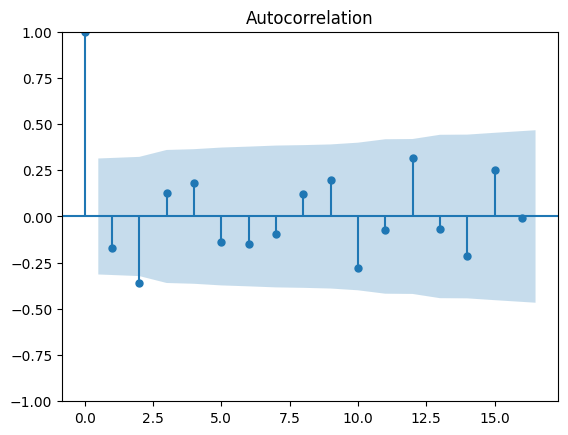

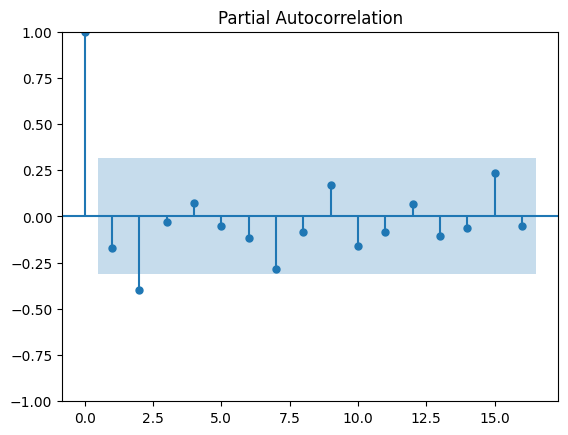

In [33]:
plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()

#### Treinamento do modelo ARIMA

In [34]:
model = ARIMA(series, order=(2, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         exportacao_usd   No. Observations:                   40
Model:                 ARIMA(2, 1, 1)   Log Likelihood                   6.350
Date:                Sun, 26 Apr 2026   AIC                             -4.701
Time:                        15:34:53   BIC                              1.954
Sample:                             0   HQIC                            -2.313
                                 - 40                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2043      0.455     -0.449      0.653      -1.096       0.687
ar.L2         -0.3870      0.228     -1.699      0.089      -0.833       0.059
ma.L1         -0.0283      0.432     -0.065      0.9

#### Diagnóstico dos resíduos

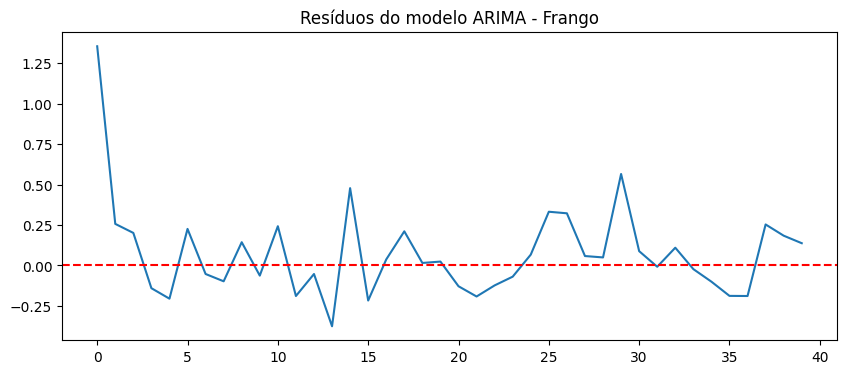

<Figure size 1000x400 with 0 Axes>

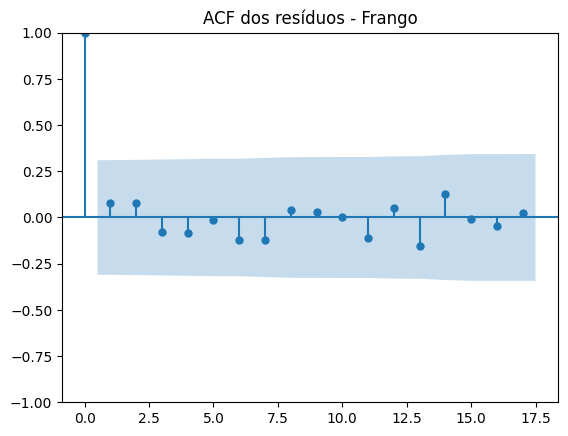

Ljung-Box test (lag 10):
     lb_stat  lb_pvalue
10  2.763471   0.986455


In [35]:
residuals = model_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos do modelo ARIMA - Frango')
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(residuals)
plt.title('ACF dos resíduos - Frango')
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print('Ljung-Box test (lag 10):')
print(lb_test)

#### Realizando previsões

In [36]:
forecast = model_fit.forecast(steps=5)

print(forecast)

40    2.313447
41    2.334632
42    2.350642
43    2.339173
44    2.335320
Name: predicted_mean, dtype: float64


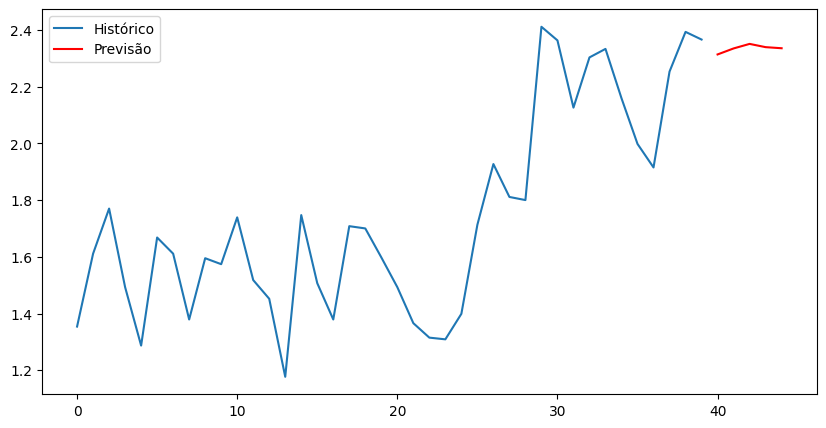

In [37]:
plt.figure(figsize=(10,5))

plt.plot(series, label='Histórico')
plt.plot(forecast, label='Previsão', color='red')

plt.legend()
plt.show()

In [38]:
train_size = int(len(series) * 0.8)

train, test = series[:train_size], series[train_size:]

model = ARIMA(train, order=(2,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 0.026739744018591406
RMSE: 0.16352291588212156
R²: 0.01792311084862308
